<a href="https://colab.research.google.com/github/adrianea132-debug/projeto-ml-ecommerce-churn/blob/main/notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

df = pd.read_csv('E Commerce Dataset - E Comm.csv')

# Tamanho da base
print("Linhas e colunas:", df.shape)

# Tipos de dados
print(df.info())

# Sumário estatístico
df.describe()

Linhas e colunas: (5630, 20)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CustomerID                   5630 non-null   int64  
 1   Churn                        5630 non-null   int64  
 2   Tenure                       5366 non-null   float64
 3   PreferredLoginDevice         5630 non-null   object 
 4   CityTier                     5630 non-null   int64  
 5   WarehouseToHome              5379 non-null   float64
 6   PreferredPaymentMode         5630 non-null   object 
 7   Gender                       5630 non-null   object 
 8   HourSpendOnApp               5375 non-null   float64
 9   NumberOfDeviceRegistered     5630 non-null   int64  
 10  PreferedOrderCat             5630 non-null   object 
 11  SatisfactionScore            5630 non-null   int64  
 12  MaritalStatus                5630 non-null   ob

,CustomerID,Churn,Tenure,CityTier,WarehouseToHome,HourSpendOnApp,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
count,5630.000000,5630.000000,5366.000000,5630.000000,5379.000000,5375.000000,5630.000000,5630.000000,5630.000000,5630.000000,5365.000000,5374.000000,5372.000000,5323.000000,5630.000000
mean,52815.500000,0.168384,10.189899,1.654707,15.639896,2.931535,3.688988,3.066785,4.214032,0.284902,15.707922,1.751023,3.008004,4.543491,177.221492
std,1625.385339,0.374240,8.557241,0.915389,8.531475,0.721926,1.023999,1.380194,2.583586,0.451408,3.675485,1.894621,2.939680,3.654433,49.193869
min,50001.000000,0.000000,0.000000,1.000000,5.000000,0.000000,1.000000,1.000000,1.000000,0.000000,11.000000,0.000000,1.000000,0.000000,0.000000
25%,51408.250000,0.000000,2.000000,1.000000,9.000000,2.000000,3.000000,2.000000,2.000000,0.000000,13.000000,1.000000,1.000000,2.000000,146.000000
50%,52815.500000,0.000000,9.000000,1.000000,14.000000,3.000000,4.000000,3.000000,3.000000,0.000000,15.000000,1.000000,2.000000,3.000000,163.000000
75%,54222.750000,0.000000,16.000000,3.000000,20.000000,3.000000,4.000000,4.000000,6.000000,1.000000,18.000000,2.000000,3.000000,7.000000,196.000000
max,55630.000000,1.000000,61.000000,3.000000,127.000000,5.000000,6.000000,5.000000,22.000000,1.000000,26.000000,16.000000,16.000000,46.000000,325.000000


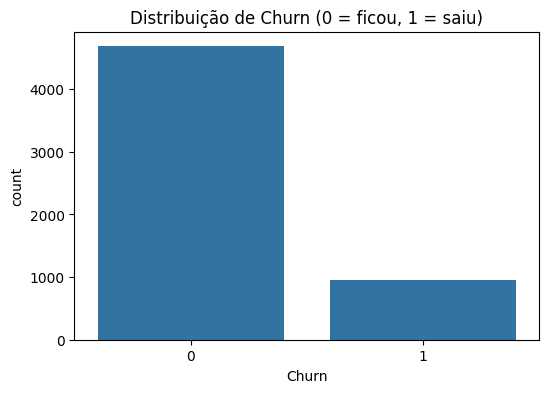

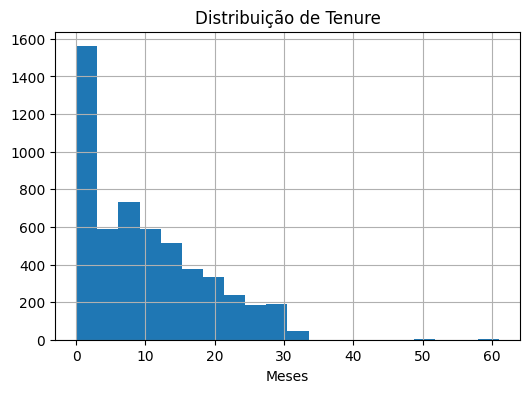

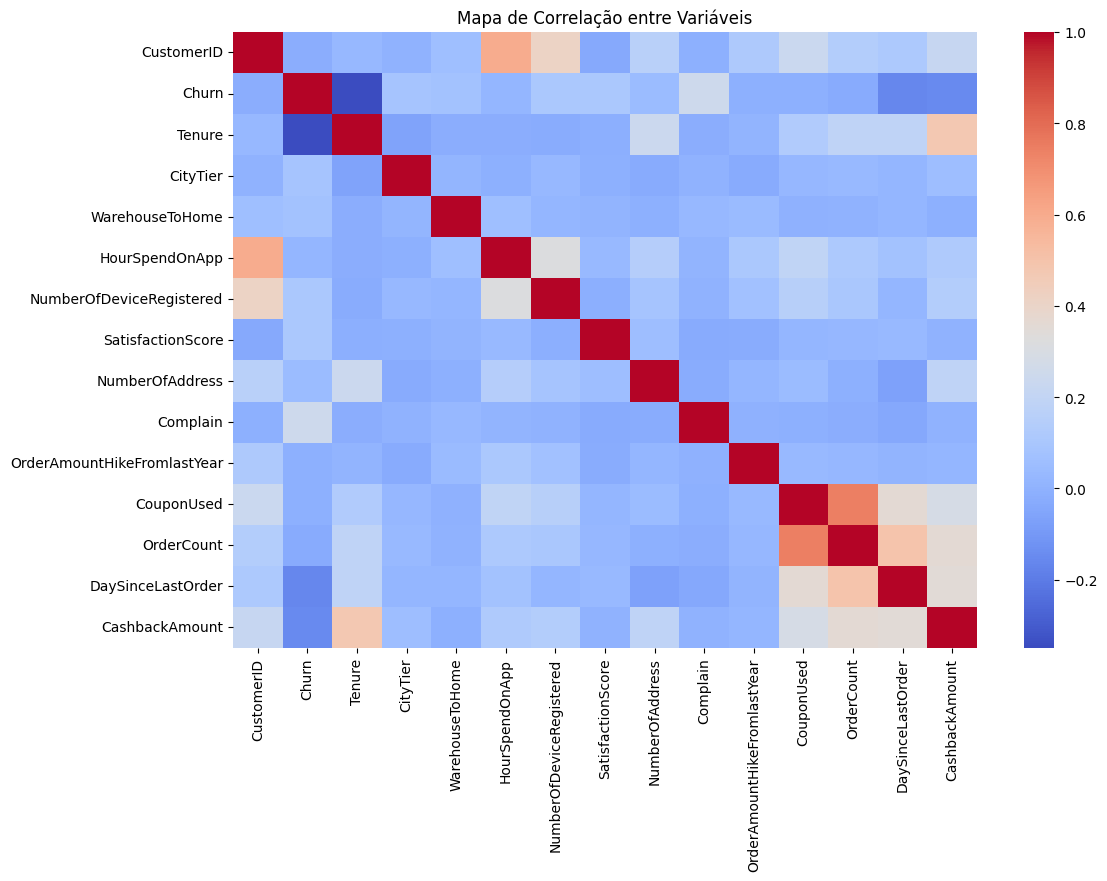

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# Gráfico 1: Desbalanceamento do Churn
plt.figure(figsize=(6,4))
sns.countplot(x='Churn', data=df)
plt.title('Distribuição de Churn (0 = ficou, 1 = saiu)')
plt.show()

# Gráfico 2: Histograma de Tenure (tempo de permanência)
plt.figure(figsize=(6,4))
df['Tenure'].hist(bins=20)
plt.title('Distribuição de Tenure')
plt.xlabel('Meses')
plt.show()

# Gráfico 3: Mapa de calor de correlação
plt.figure(figsize=(12,8))
sns.heatmap(df.select_dtypes(include='number').corr(), annot=False, cmap='coolwarm')
plt.title('Mapa de Correlação entre Variáveis')
plt.show()

## Análise Exploratória — Insights

Olhando o gráfico de Churn, o que mais me chamou atenção foi que só ~17% dos clientes cancelam. Isso é bom, mas complica o treino do modelo: sem balancear as classes, o algoritmo pode simplesmente aprender a prever que ninguém cancela. Por isso vou usar SMOTE antes de treinar os modelos.

No gráfico de Tenure, a maioria dos clientes é nova, concentrada entre 0 e 20 meses. Como a distribuição é assimétrica, vou usar a mediana (não a média) pra preencher os nulos dessa coluna.

No mapa de correlação, notei que uso de cupons (CouponUsed) está relacionado com mais pedidos (OrderCount) e compras mais recentes (DaySinceLastOrder) — sinal de que cupons ajudam a manter o cliente ativo, o que conecta direto com o desafio de negócio do projeto.

In [3]:
# Verificar nulos
print(df.isnull().sum().sort_values(ascending=False))

# Verificar duplicadas
print("\nLinhas duplicadas:", df.duplicated().sum())

DaySinceLastOrder              307
OrderAmountHikeFromlastYear    265
Tenure                         264
OrderCount                     258
CouponUsed                     256
HourSpendOnApp                 255
WarehouseToHome                251
CustomerID                       0
PreferredLoginDevice             0
Churn                            0
PreferredPaymentMode             0
CityTier                         0
SatisfactionScore                0
PreferedOrderCat                 0
NumberOfDeviceRegistered         0
Gender                           0
Complain                         0
NumberOfAddress                  0
MaritalStatus                    0
CashbackAmount                   0
dtype: int64

Linhas duplicadas: 0
